The following script performs EEG data preprocessing through several steps:
1. Read raw file
2. Band pass filter 1 to 45hz
3. Crop signal from tmin to tmax
4. Visual inspection of channels. Drop bads
5. Epochs of -0.3s to 1.2s
6. Autoreject Epochs
7. Manual inspection of Epochs
8. ICA
9. Interpolate bad channels
10. Rereferenced to grand average

In [1]:

# This magic command allows interactive plotting in a separate window
%matplotlib qt

# Import necessary libraries for the preprocessing
import os
from git import Repo
import numpy as np

import matplotlib.pyplot as plt

import mne
from mne_bids import BIDSPath, read_raw_bids #,print_dir_tree
# Importing libraries for automatic rejection of bad epochs
from autoreject import AutoReject, get_rejection_threshold
from pyprep import NoisyChannels


# tag automatically ICA components
# requires pytorch
from mne_icalabel import label_components

# Import helper functions for preprocessing
from utils.log_preprocessing import LogPreprocessingDetails
from utils.bids_compliance import read_raw_custom, save_raw_bids_compliant, save_epoched_bids,make_bids_basename
from utils.preprocessing_helpers import set_chs_montage
from utils.trigger_correction import TriggerCorrector


2024-10-08 14:41:44,876 - numexpr.utils - INFO - Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2024-10-08 14:41:44,877 - numexpr.utils - INFO - NumExpr defaulting to 16 threads.


# 1. Load Data

In [2]:
##################################
#####          LOAD          #####
##################################
data_root ="//l2export/iss02.cenir/analyse/meeg/CYBERSART/"
# Define the file path components
raw_path ="//l2export/iss02.cenir/analyse/meeg/CYBERSART/_RAW_DATA/"

#select subject and task
id = "10"
subject = f'S0{id}'
task = 'Sart1'  # Could be 'Sart1', 'Sart2', etc.
data = 'eeg'

##################################
#####      FOR SAVING        #####
##################################
# Defining the paths for saving results and raw data
derivatives_folder = os.path.join(data_root, "derivatives_nico")
derivative_bids_dir = os.path.join(derivatives_folder, f"sub-{id}", "eeg")
os.makedirs(derivative_bids_dir, exist_ok=True)

# Initialize a report to document the preprocessing steps
report = mne.Report(
    title=f"Preprocessing sub-{subject} for {task}", verbose = False
)

# Path to the JSON file where preprocessing details will be stored
json_path = os.path.join(
    derivatives_folder, "logs_preprocessing_details_all_subjects_eeg.json"
)

# Initialize the logging class
log_preprocessing = LogPreprocessingDetails(json_path, subject,task)

##################################
########   1.READ RAW   ##########
##################################
raw = read_raw_custom(subject,task, root=raw_path)

#set channel montage
raw = set_chs_montage(raw)

# import bad chs from another task of same session
# Important to check if also bad!!!
raw.info["bads"] = log_preprocessing.import_bad_channels_another_task()

print(raw.info)

# Plot sensor location in the scalp
# raw.plot_sensors(show_names=True)
# plt.show()

# Add the raw data info to the report
report.add_raw(raw=raw, title="Raw", psd=True)

# Log the raw data info
log_preprocessing.log_detail("info", str(raw.info))

Reading data for subject S010, task Sart1, date 2020-01-31
Extracting parameters from //l2export/iss02.cenir/analyse/meeg/CYBERSART/_RAW_DATA/sub-S010\eeg\CYBERSART_2020-01-31_Sart1.vhdr...
Setting channel info structure...
<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, CP5, CP1, Pz, P3, ...
 chs: 64 EEG, 2 EOG
 custom_ref_applied: False
 dig: 68 items (3 Cardinal, 65 EEG)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 66
 projs: []
 sfreq: 1000.0 Hz
>
Using matplotlib as 2D backend.


c:\Users\nicolas.bruno\Documents\GitHub\depressed_mindwandering\Preprocessing\utils\preprocessing_helpers.py:16: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw.set_montage(montage)


Channels marked as bad:
none
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


# 2.FILTERING

In [3]:
# Apply a band-pass filter to keep frequencies between 1 and 45 Hz
hpass = 0.5
lpass = 45
raw_filtered = raw.load_data().copy().notch_filter(np.arange(50, 250, 50)).filter(l_freq=hpass, h_freq=lpass)

# Save the filtered data
# bids_path.update(root = derivatives_folder, description = 'filtered')
# write_raw_bids(raw_filtered, bids_path, format='BrainVision', allow_preload=True, overwrite=True)

# Log the filter settings
log_preprocessing.log_detail("hpass_filter", hpass)
log_preprocessing.log_detail("lpass_filter", lpass)
log_preprocessing.log_detail("filter_type", "bandpass")

Reading 0 ... 1132919  =      0.000 ...  1132.919 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


# 3.Visual inspection of CHs

In [4]:
# Plots PSD of the raw data
raw_filtered.compute_psd().plot()

#automatically mark bad channels
nd = NoisyChannels(raw_filtered,do_detrend = False, random_state=42)
nd.find_all_bads(ransac=True, channel_wise=True) #if it slows down, set channel_wise to False
bads = nd.get_bads()
print(f"Bad channels detected: {bads}")
if bads != None:
    raw_filtered.info["bads"] = bads

# Plot the filtered data for visual inspection to identify bad channels
raw_filtered.plot(n_channels=32)
plt.show(block=True)

# Add the filtered data to the report
report.add_raw(raw=raw_filtered, title="Filtered Raw", psd=True)

# Log the identified bad channels
log_preprocessing.log_detail("bad_channels", raw_filtered.info["bads"])

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Executing RANSAC
This may take a while, so be patient...
Finding optimal chunk size : 21
Total # of chunks: 3
Current chunk:
1
2
3

RANSAC done!
Bad channels detected: ['FC1', np.str_('C2')]
Channels marked as bad:
['FC1', np.str_('C2')]
Channels marked as bad:
['FC1', np.str_('C2')]
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


# 4. EPOCHING

In [5]:
##################################
######    LOAD TRIGGGERS   #######
##################################
# recode annotations
processor = TriggerCorrector(raw_filtered)
# get the recoded events and event_id
events, event_id = processor.process_annotations()
#filter out all non go nogo events
# Filter the event_id for 'go' and 'nogo' events
go_nogo_event_id = {key: value for key, value in event_id.items() if 'go' in key or 'nogo' in key}

# Segment the continuous data into epochs of 2 seconds
tmin = -0.3
tmax = 1.2
# baseline correction should be done after ICA
epochs = mne.Epochs(
    raw_filtered,
    events=events,
    event_id=go_nogo_event_id,
    tmin=tmin,
    tmax=tmax,
    preload=False,
    verbose=False,
)

# Save the epoched data
# bids_compliance.save_epoched_bids(epochs, derivatives_folder, subject, session,
#                                   task, data, desc = 'epoched', events = events, event_id =event_id)

# Add the epochs to the report
report.add_epochs(epochs=epochs, title="Epochs")

# Log the number of epochs and their duration
log_preprocessing.log_detail("n_epochs", len(epochs))
log_preprocessing.log_detail("tmin", tmin)
log_preprocessing.log_detail("tmax", tmax)

Used Annotations descriptions: [np.str_('Comment/actiCAP Data On'), np.str_('New Segment/'), np.str_('Stimulus/S 21'), np.str_('Stimulus/S 22'), np.str_('Stimulus/S 23'), np.str_('Stimulus/S 24'), np.str_('Stimulus/S 25'), np.str_('Stimulus/S 31'), np.str_('Stimulus/S 32'), np.str_('Stimulus/S 33'), np.str_('Stimulus/S 34'), np.str_('Stimulus/S 35'), np.str_('Stimulus/S 36'), np.str_('Stimulus/S 41'), np.str_('Stimulus/S 42'), np.str_('Stimulus/S 43'), np.str_('Stimulus/S 44'), np.str_('Stimulus/S 45'), np.str_('Stimulus/S115'), np.str_('Stimulus/S122'), np.str_('Stimulus/S125'), np.str_('Stimulus/S127'), np.str_('Stimulus/S128'), np.str_('Stimulus/S130'), np.str_('Stimulus/S131'), np.str_('Stimulus/S133'), np.str_('Stimulus/S134'), np.str_('Stimulus/S135'), np.str_('Stimulus/S137'), np.str_('Stimulus/S138'), np.str_('Stimulus/S139'), np.str_('Stimulus/S140'), np.str_('Stimulus/S141'), np.str_('Stimulus/S142'), np.str_('Stimulus/S143'), np.str_('Stimulus/S146'), np.str_('Stimulus/S147'

# 5. Reject Bad Epochs 1

In [6]:
# TODO: add rejection for acceloremeter (available from sub 14 onwards)
folds=5 # increase for more accuracy or decrease for speed
# Automatically reject bad epochs using AutoReject
ar = AutoReject(thresh_method="bayesian_optimization", cv = folds, random_state=42, n_jobs = -1, )
epochs_clean = ar.fit_transform(epochs)
reject = get_rejection_threshold(epochs)

ar.get_reject_log(epochs).plot('horizontal')

# Log the epochs rejected by AutoReject
ar_reject_epochs = [
    n_epoch
    for n_epoch, log in enumerate(epochs_clean.drop_log)
    if log == ("AUTOREJECT",)
]

log_preprocessing.log_detail("autoreject_epochs", ar_reject_epochs)
log_preprocessing.log_detail("autoreject_threshold", reject)
log_preprocessing.log_detail("len_autoreject_epochs", len(ar_reject_epochs))

c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\autoreject\utils.py:73: UserWarning: 2 channels are marked as bad. These will be ignored. If you want them to be considered by autoreject please remove them from epochs.info["bads"].
  warnings.warn(
c:\Users\nicolas.bruno\AppData\Local\anaconda3\envs\mne\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running autoreject on ch_type=eeg


100%|██████████| Creating augmented epochs : 62/62 [00:09<00:00,    6.30it/s]
100%|██████████| Computing thresholds ... : 62/62 [00:35<00:00,    1.73it/s]



































































































































































































































































































































































































































































100%|██████████| Repairing epochs : 450/450 [00:44<00:00,   10.07it/s]









































































































































































































































































































































Estimated consensus=0.60 and n_interpolate=32





































































































































































































































































































































































































































































100%|██████████| Repairing epochs : 450/450 [01:00<00:00,    7.46it/s]

Dropped 56 epochs: 13, 19, 28, 31, 34, 36, 37, 39, 41, 42, 49, 50, 61, 65, 66, 69, 84, 85, 89, 90, 91, 95, 96, 98, 99, 100, 103, 105, 106, 107, 111, 115, 118, 122, 127, 145, 146, 147, 153, 165, 166, 171, 210, 212, 213, 249, 266, 270, 287, 288, 295, 296, 297, 361, 403, 448


Estimating rejection dictionary for eeg
Estimating rejection dictionary for eog


In [7]:
# epochs_clean = epochs  # to skip autoreject
# ar_reject_epochs = []  # to skip autoreject
#Manually inspect and reject bad epochs
epochs_clean.plot(n_channels=32)
plt.show(block=True)

# Log the epochs rejected manually
manual_reject_epochs = [
    n_epoch for n_epoch, log in enumerate(epochs_clean.drop_log) if log == ("USER",)
]
print(f"Manually rejected epochs: {manual_reject_epochs}")
total_epochs_rejected = (
    (len(ar_reject_epochs) + len(manual_reject_epochs)) / len(epochs) * 100
)
print(f"Total epochs rejected: {total_epochs_rejected}%")
log_preprocessing.log_detail("manual_reject_epochs", manual_reject_epochs)
log_preprocessing.log_detail("len_manual_reject_epochs", len(manual_reject_epochs))

# Plot the drop log for further inspection
epochs_clean.plot_drop_log()

# Add the cleaned epochs to the report
report.add_epochs(epochs=epochs_clean, title="Epochs clean", psd=False)

# Save the cleaned epochs
epochs_clean.drop_bad()
# bids_compliance.save_epoched_bids(epochs_clean, derivatives_folder, subject, session,
#                                   task, data, desc = 'epochedClean', events = events, event_id =event_id)

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
['FC1', np.str_('C2')]
Manually rejected epochs: []
Total epochs rejected: 12.444444444444445%


# 6. Independent Component Analysis (ICA)

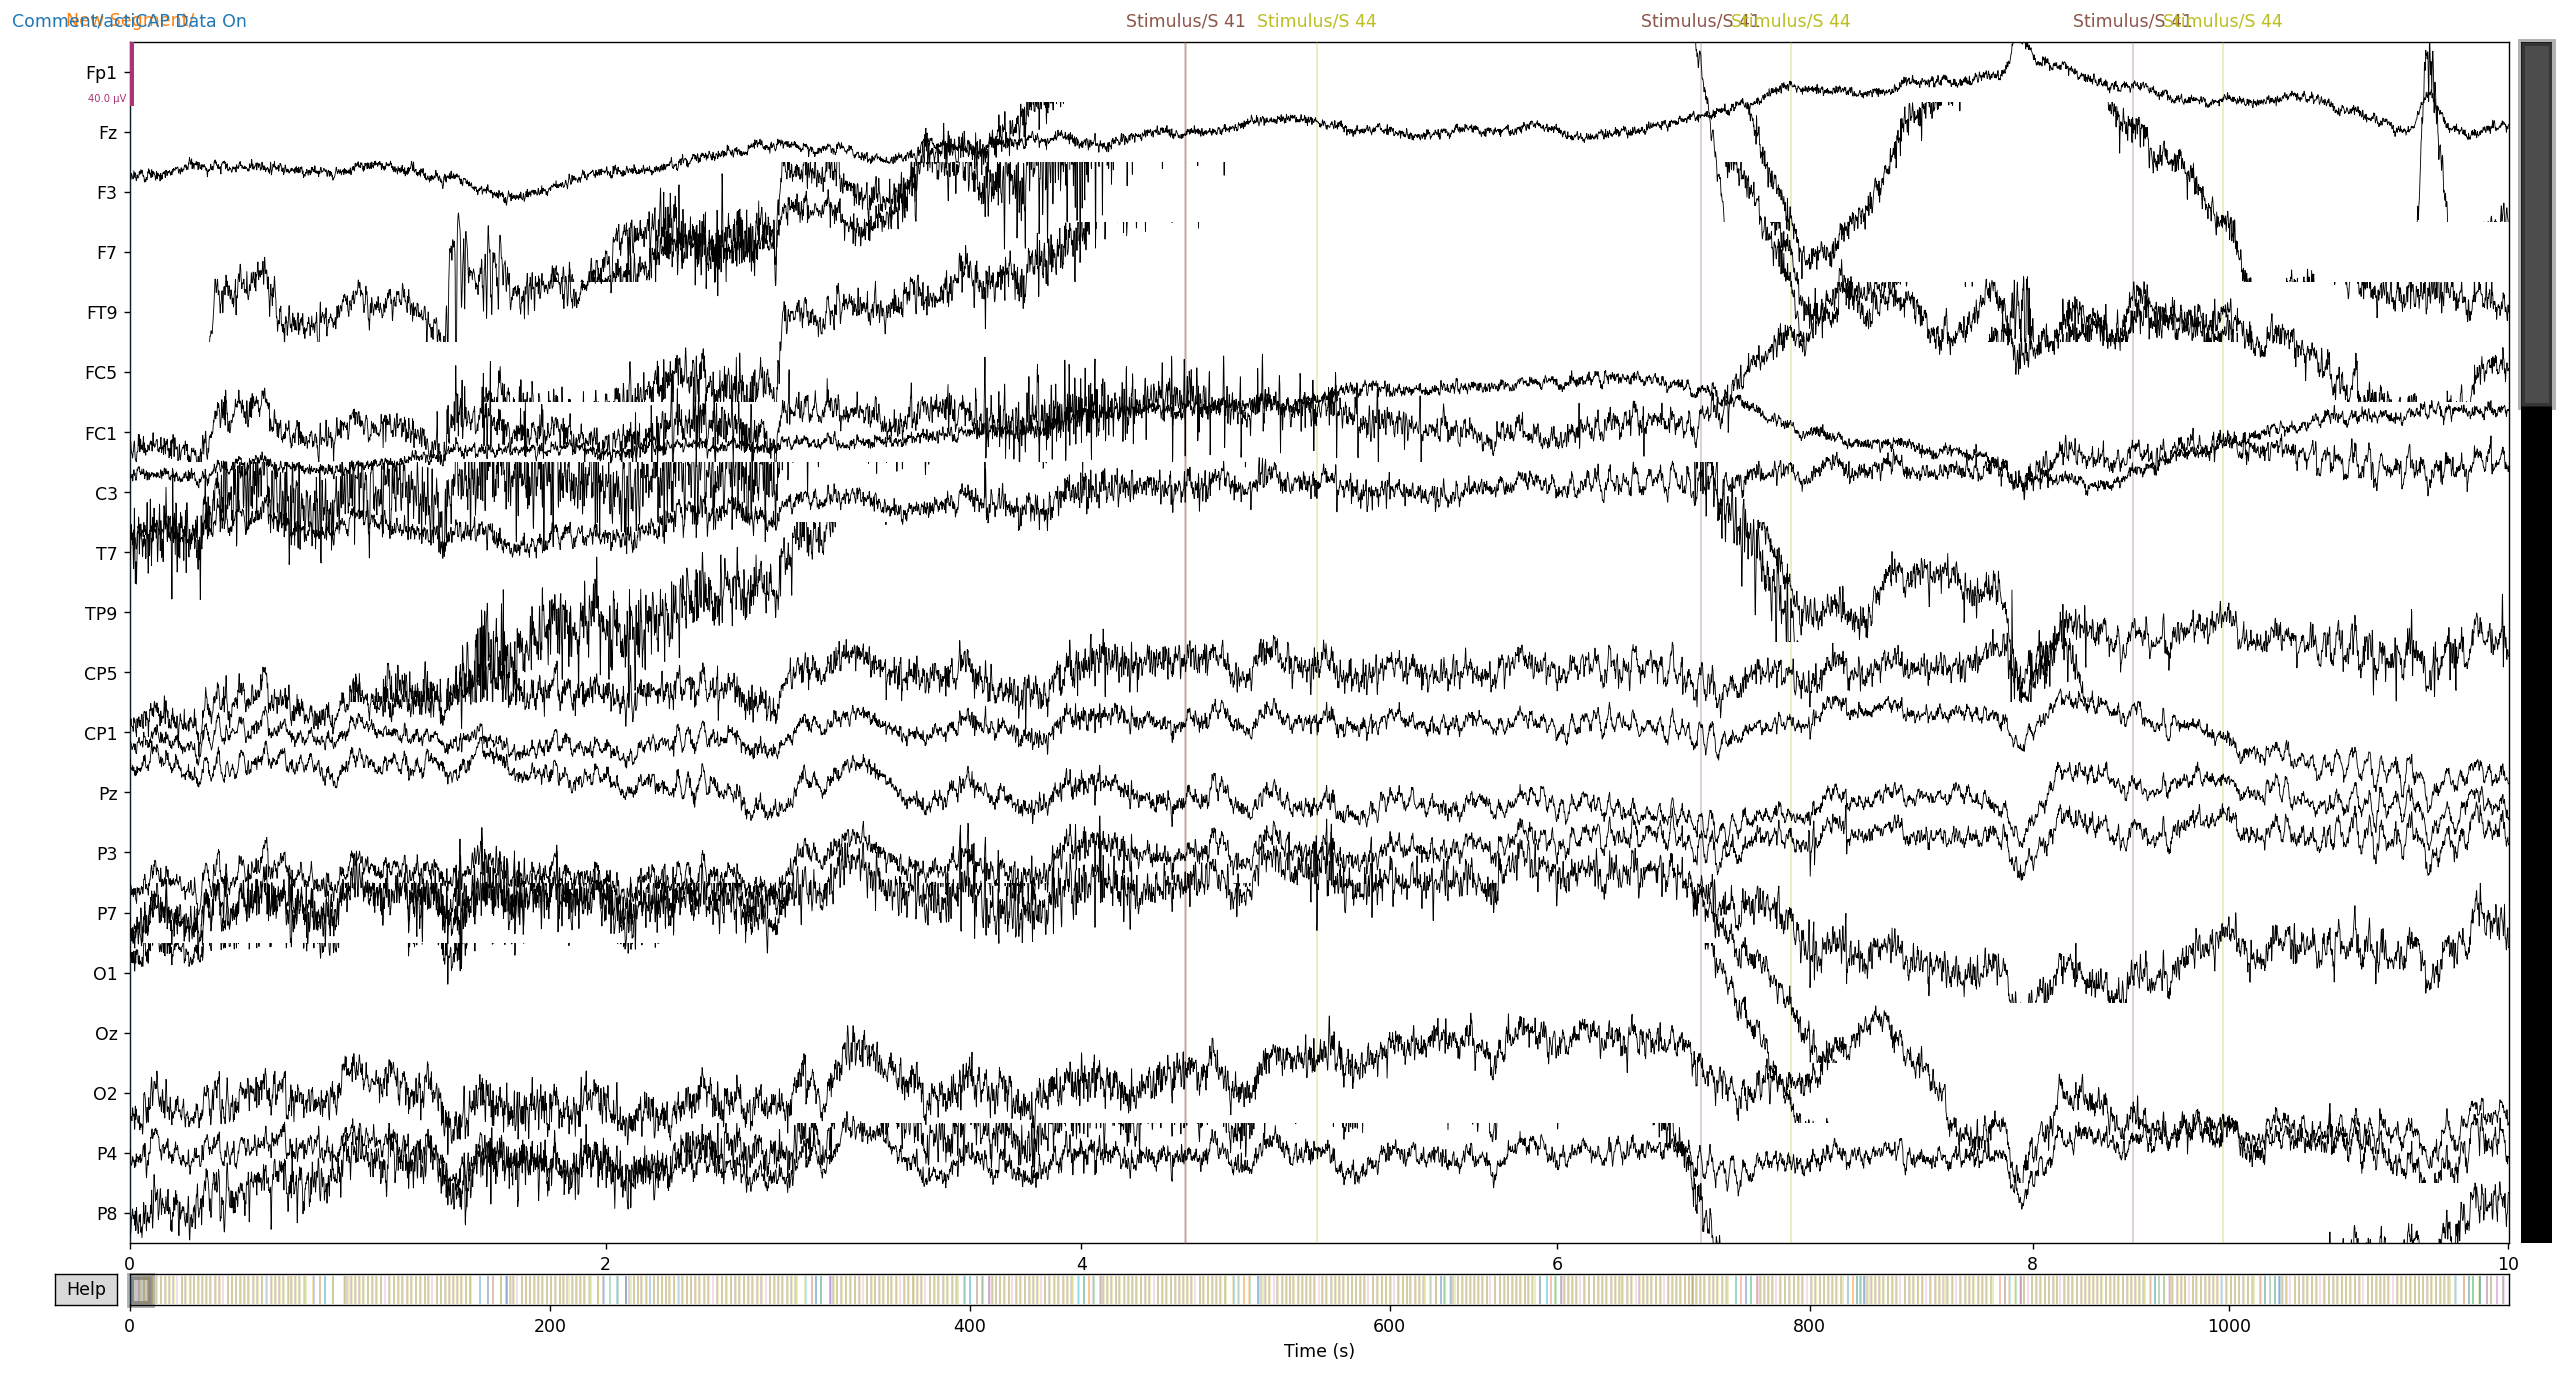

Channels marked as bad:
none


In [9]:
raw.plot()

In [10]:
# Parameters for ICA (Independent Component Analysis) to remove artifacts
n_components = 15
method = "picard"  # The algorithm to use for ICA
max_iter = (
    "auto"  # Maximum number of iterations; typically should be higher, like 500 or 1000
)
random_state = 42  # Seed for random number generator for reproducibility

# Initialize the ICA object with the specified parameters
ica = mne.preprocessing.ICA(
    n_components=n_components,
    method=method,
    max_iter=max_iter,
    random_state=random_state,
)

# Fit the ICA model to the cleaned epochs
ica.fit(epochs_clean)

# find EOG artifacts in the data via pattern matching, and exclude the EOG-related ICA components
eog_components, eog_scores = ica.find_bads_eog(
    inst=epochs_clean,
    ch_name=["VEOG","HEOG"]  # a channel close to the eye
    # threshold=1  # lower than the default threshold
)
print(f"EOG components detected: {eog_components}")

# find muscle artifacts in the data via pattern matching, and exclude the muscle-related ICA components
muscle_components, muscle_scores = ica.find_bads_muscle(epochs_clean, threshold=0.7)
print(f"Muscle components detected: {muscle_components}")
# ica.plot_scores(muscle_scores, exclude=muscle_components)

# Combine all artifact components from the pattern matching methods
pattern_matching_artifacts = np.unique(eog_components + muscle_components)

##### Classify the components using ICLabel model #######
# run the model on the ICA components
ic_labels = label_components(epochs_clean, ica, method="iclabel")
# print labels of each component
print("Classification of all ICA components. Results:")
print(ic_labels["labels"])

# Extract ICA component labels
label_names = ic_labels['labels']

# Identify the ICA components that correspond to a 'channel noise' in ICLabel
channel_artifact_indices = [i for i, label in enumerate(label_names) if label == 'channel noise']
cardiac_artifact_indices = [i for i, label in enumerate(label_names) if label == 'heart']


# Find components that coincide between pattern matching and ICLabel output for exclusion
# We'll only exclude components that match the artifacts found via pattern matching 
# and are classified as 'muscle artifact', 'eye blink', 'heart beat', or 'channel noise'
to_exclude = []
for idx in pattern_matching_artifacts:
    if label_names[idx] in ['muscle artifact', 'eye blink', 'heart beat', 'channel noise']:
        to_exclude.append(idx)

# Also ensure to include 'channel noise' components that were found only by ICLabel
to_exclude = np.unique(to_exclude + channel_artifact_indices + cardiac_artifact_indices)

# Exclude the selected components
ica.exclude = to_exclude.tolist()

# (Optional) Plot the ICA components for visual inspection
# ica.plot_components(inst=epochs_clean, picks=range(15))

# Plot the sources identified by ICA
ica.plot_sources(epochs_clean, block=True, show=True)
plt.show(block=True)

# Add the ICA results to the report
report.add_ica(ica, title="ICA", inst=epochs_clean)

# Apply the ICA solution to the cleaned epochs
epochs_ica = ica.apply(inst=epochs_clean)

# Log the ICA parameters and excluded components
log_preprocessing.log_detail("ica_components", ica.exclude)
log_preprocessing.log_detail("ica_method", method)
log_preprocessing.log_detail("ica_max_iter", max_iter)
log_preprocessing.log_detail("ica_random_state", random_state)

Fitting ICA to data using 62 channels (please be patient, this may take a while)


C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_31140\3310635659.py:18: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs_clean)


Selecting by number: 15 components
Fitting ICA took 19.8s.
Using EOG channels: VEOG, HEOG
EOG components detected: [np.int64(0)]
    Using multitaper spectrum estimation with 7 DPSS windows
Muscle components detected: [7, 8, 9, 11, 13]


C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_31140\3310635659.py:38: RuntimeWarning: The provided Epochs instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels = label_components(epochs_clean, ica, method="iclabel")
C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_31140\3310635659.py:38: RuntimeWarning: The provided Epochs instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(epochs_clean, ica, method="iclabel")
C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_31140\3310635659.py:38: RuntimeWarning: The provided ICA instance was fitted with a 'picard' algorithm. ICLabel was designed with exte

Classification of all ICA components. Results:
['eye blink', 'other', 'other', 'other', 'other', 'eye blink', 'brain', 'eye blink', 'eye blink', 'brain', 'other', 'eye blink', 'eye blink', 'eye blink', 'brain']
Not setting metadata
394 matching events found
No baseline correction applied
0 projection items activated


C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_31140\3310635659.py:69: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  ica.plot_sources(epochs_clean, block=True, show=True)


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
394 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
394 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
394 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
394 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
394 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
394 matching events found
No baseline correction applied
0 projection items activated
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
394 matching events found
No baseline correction applied
0 projection items activated
Not set

C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_31140\3310635659.py:76: RuntimeWarning: The data you passed to ICA.apply() was baseline-corrected. Please note that ICA can introduce DC shifts, therefore you may wish to consider baseline-correcting the cleaned data again.
  epochs_ica = ica.apply(inst=epochs_clean)


In [ ]:
##### FINAL EPOCH CLEANING #######
baseline = (-0.3, 0)  # to be done after ICA!
epochs_ica.apply_baseline(baseline)
log_preprocessing.log_detail("baseline", baseline)

# Manually inspect the epochs after ICA application
epochs_ica.plot(n_channels=32)
plt.show(block=True)

# Log manually rejected epochs after ICA
all_manual_epochs = [
    n_epoch for n_epoch, log in enumerate(epochs_ica.drop_log) if log == ("USER",)
]
manual_reject_epochs_after_ica = [
    n_epoch for n_epoch in all_manual_epochs if n_epoch not in manual_reject_epochs
]
print(f"Manually rejected epochs after ICA: {manual_reject_epochs_after_ica}")
total_epochs_rejected = (
(len(ar_reject_epochs)+len(manual_reject_epochs)+len(manual_reject_epochs_after_ica)
    )/ len(epochs) * 100
)
print(f"Total epochs rejected: {total_epochs_rejected}%")
log_preprocessing.log_detail("manual_reject_epochs_after_ica", manual_reject_epochs_after_ica)
log_preprocessing.log_detail("len_manual_reject_epochs_after_ica", len(manual_reject_epochs_after_ica))
log_preprocessing.log_detail("total_epochs_rejected", total_epochs_rejected)
log_preprocessing.log_detail("epochs_drop_log", epochs_ica.drop_log)
log_preprocessing.log_detail("epochs_drop_log_description", epochs_ica.drop_log)

# Save the epochs after ICA application and drop epochs
# bids_compliance.save_epoched_bids(epochs_ica, derivatives_folder, subject, session,
#                                   task, data, desc = 'epochedICA', events = events, event_id =event_id)

# 7. Interpolate Chs and Rereference

In [25]:
##################################
#######    Rereference   #########
##################################
epochs_ica = mne.add_reference_channels(epochs_ica.load_data(), ref_channels=["FCz"])

# Path to your .bvef file
bvef_file_path = './CACS-64_withREF.bvef'
# Load the extended montage
montage = mne.channels.read_custom_montage(bvef_file_path)

# Apply the montage to your raw data
epochs_ica.set_montage(montage)


# Rereference the data to the grand average reference
epochs_rereferenced, ref_data = mne.set_eeg_reference(
    inst=epochs_ica, ref_channels="average", copy=True
)

# Add the final epochs to the report
report.add_epochs(
    epochs=epochs_rereferenced, title="Epochs interpolated and rereferenced", psd=True
)

# Log the rereferencing details
log_preprocessing.log_detail("rereferenced_channels", "grand_average")


##################################
######   Interpolate chs  ########
##################################
# Interpolate bad channels in the epochs after ICA application
epochs_interpolate = epochs_rereferenced.copy().interpolate_bads()

# Log the interpolated channels
log_preprocessing.log_detail("interpolated_channels", epochs_ica.info["bads"])

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


C:\Users\nicolas.bruno\AppData\Local\Temp\ipykernel_31140\2352351564.py:12: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  epochs_ica.set_montage(montage)


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 63 sensor positions
Interpolating 2 sensors


# SAVE Preprocessed data 

In [22]:
# Save the rereferenced epochs
save_epoched_bids(
    epochs_interpolate,
    derivatives_folder,
    subject,
    task,
    data,
    desc="preproc",
    events=events,
    event_id=event_id,
)

# Save the report as an HTML file
html_report_fname = make_bids_basename(
    subject=subject,
    task=task,
    suffix=data,
    extension=".html",
    desc="preprocReport",
)
report.save(os.path.join(derivative_bids_dir, html_report_fname), overwrite=True)

# Save the preprocessing details to the JSON file
log_preprocessing.save_preprocessing_details()

TypeError: save_epoched_bids() missing 1 required positional argument: 'data'

Optional: Observe Preprocessed Data 

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


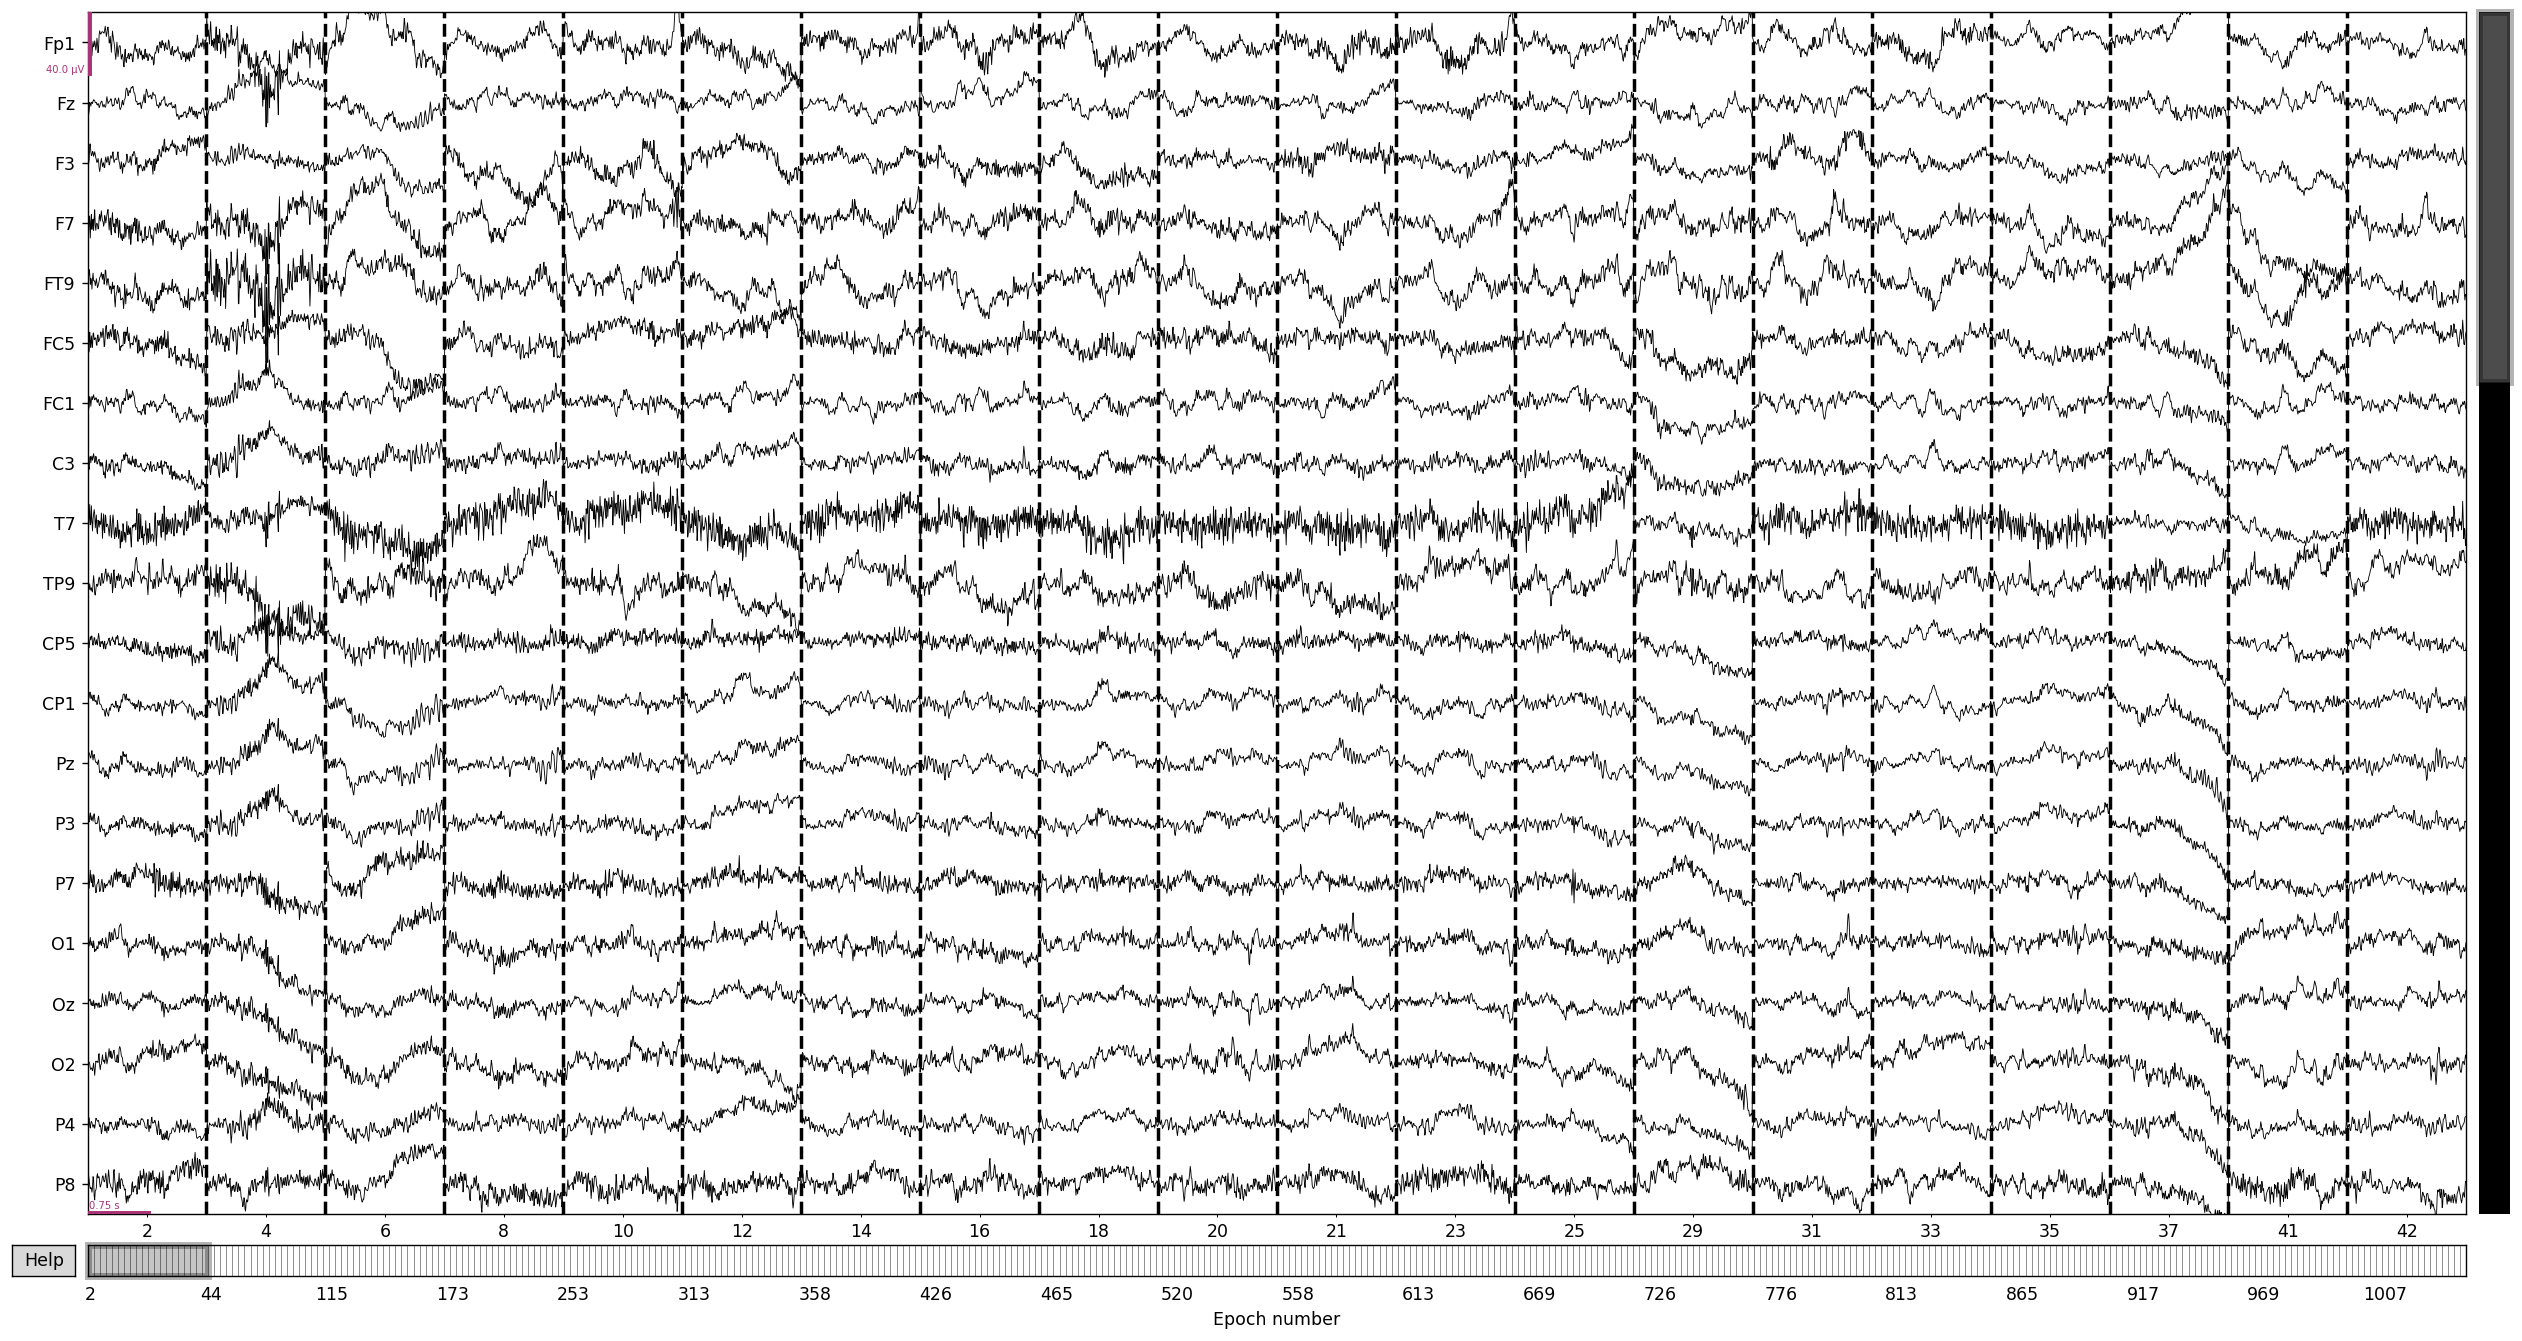

Dropped 2 epochs: 23, 30
The following epochs were marked as bad and are dropped:
[np.int64(50), np.int64(70)]
Channels marked as bad:
none


In [19]:
epochs_interpolate.plot_psd()
epochs_interpolate.plot()

### Plot difference in the ERPs of the Go vs Nogo condition
It helps as validation. We should expect some difference curve around 300 and 500ms

In [24]:
mne.combine_evoked([ epochs_interpolate['go/correct'].average(), epochs_interpolate['nogo/correct'].average()], weights=[1,-1]).plot_joint([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]);

No projector specified for this dataset. Please consider the method self.add_proj.
